In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [32]:
df=pd.read_csv('rock_density_xray.csv')

In [33]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [34]:
df.columns=['Signal','Density']

<Axes: xlabel='Signal', ylabel='Density'>

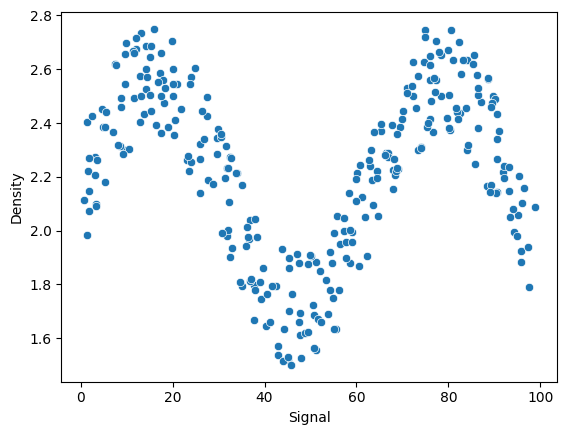

In [35]:
sns.scatterplot(x='Signal',y='Density',data=df)

In [36]:
X=df['Signal'].values.reshape(-1,1)
y=df['Density']

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=101)

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lr=LinearRegression()

In [41]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
lr_preds=lr.predict(X_test)

In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [44]:
mean_absolute_error(y_test,lr_preds)

0.211198973318633

In [45]:
np.sqrt(mean_squared_error(y_test,lr_preds))

np.float64(0.2570051996584629)

In [46]:
signal_range=np.arange(0,100)

In [47]:
signal_preds=lr.predict(signal_range.reshape(-1,1))

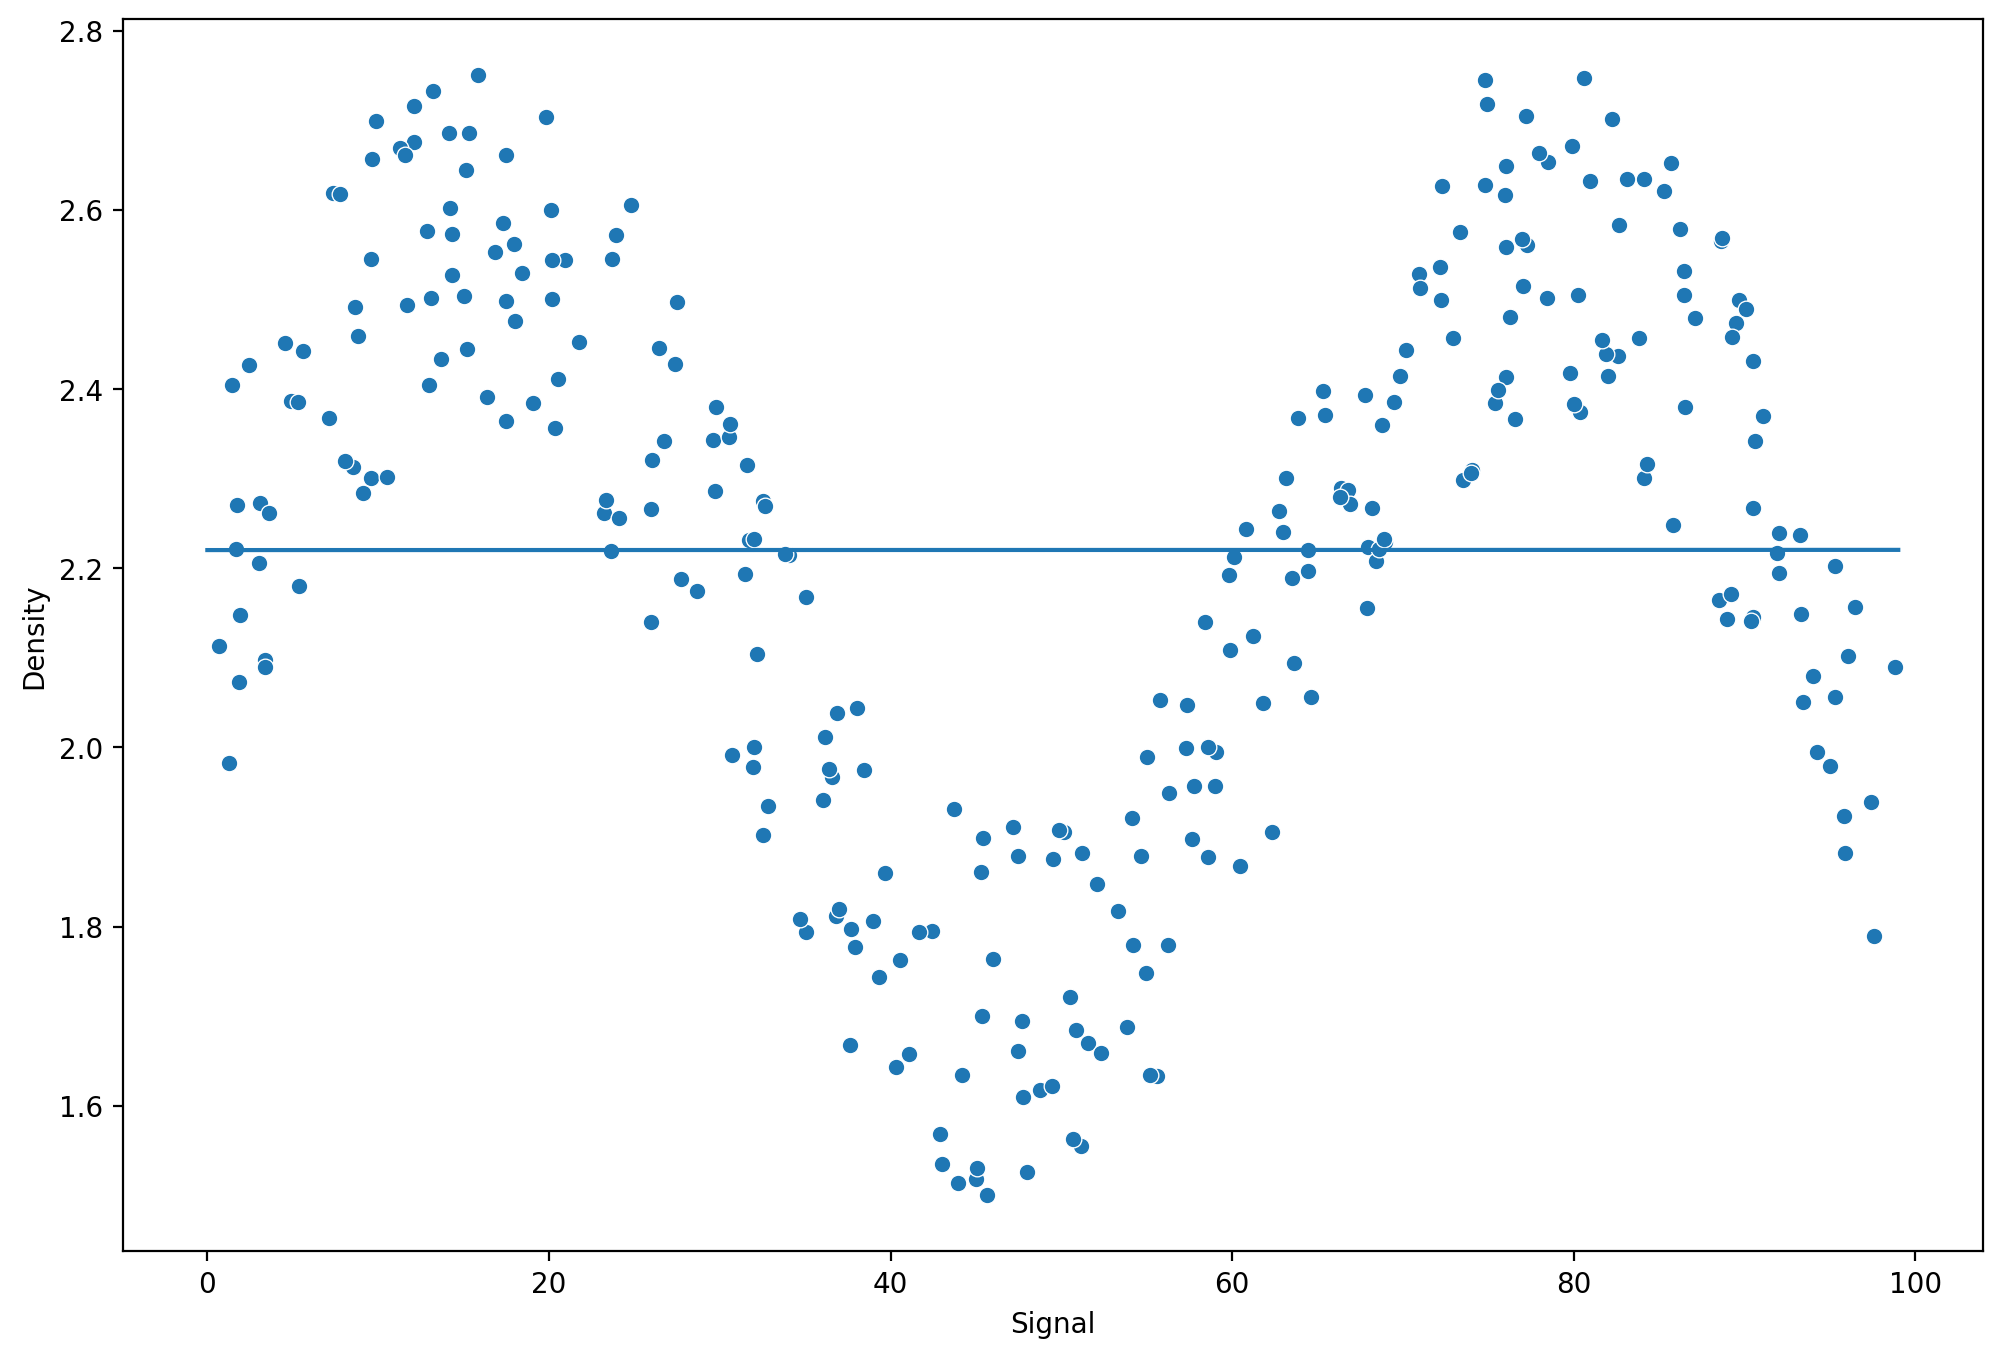

In [48]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

plt.plot(signal_range,signal_preds)

In [53]:
def run_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)

    preds=model.predict(X_test)
    rmse=np.sqrt(mean_squared_error(y_test,preds))
    mae=mean_absolute_error(y_test,preds)
    print(f'RMSE:{rmse}')
    print(f'MAE:{mae}')

    signal_range=np.arange(0,100)
    signal_preds=model.predict(signal_range.reshape(-1,1))
    plt.figure(figsize=(12,8),dpi=200)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')

    plt.plot(signal_range,signal_preds)

RMSE:0.2570051996584629
MAE:0.211198973318633


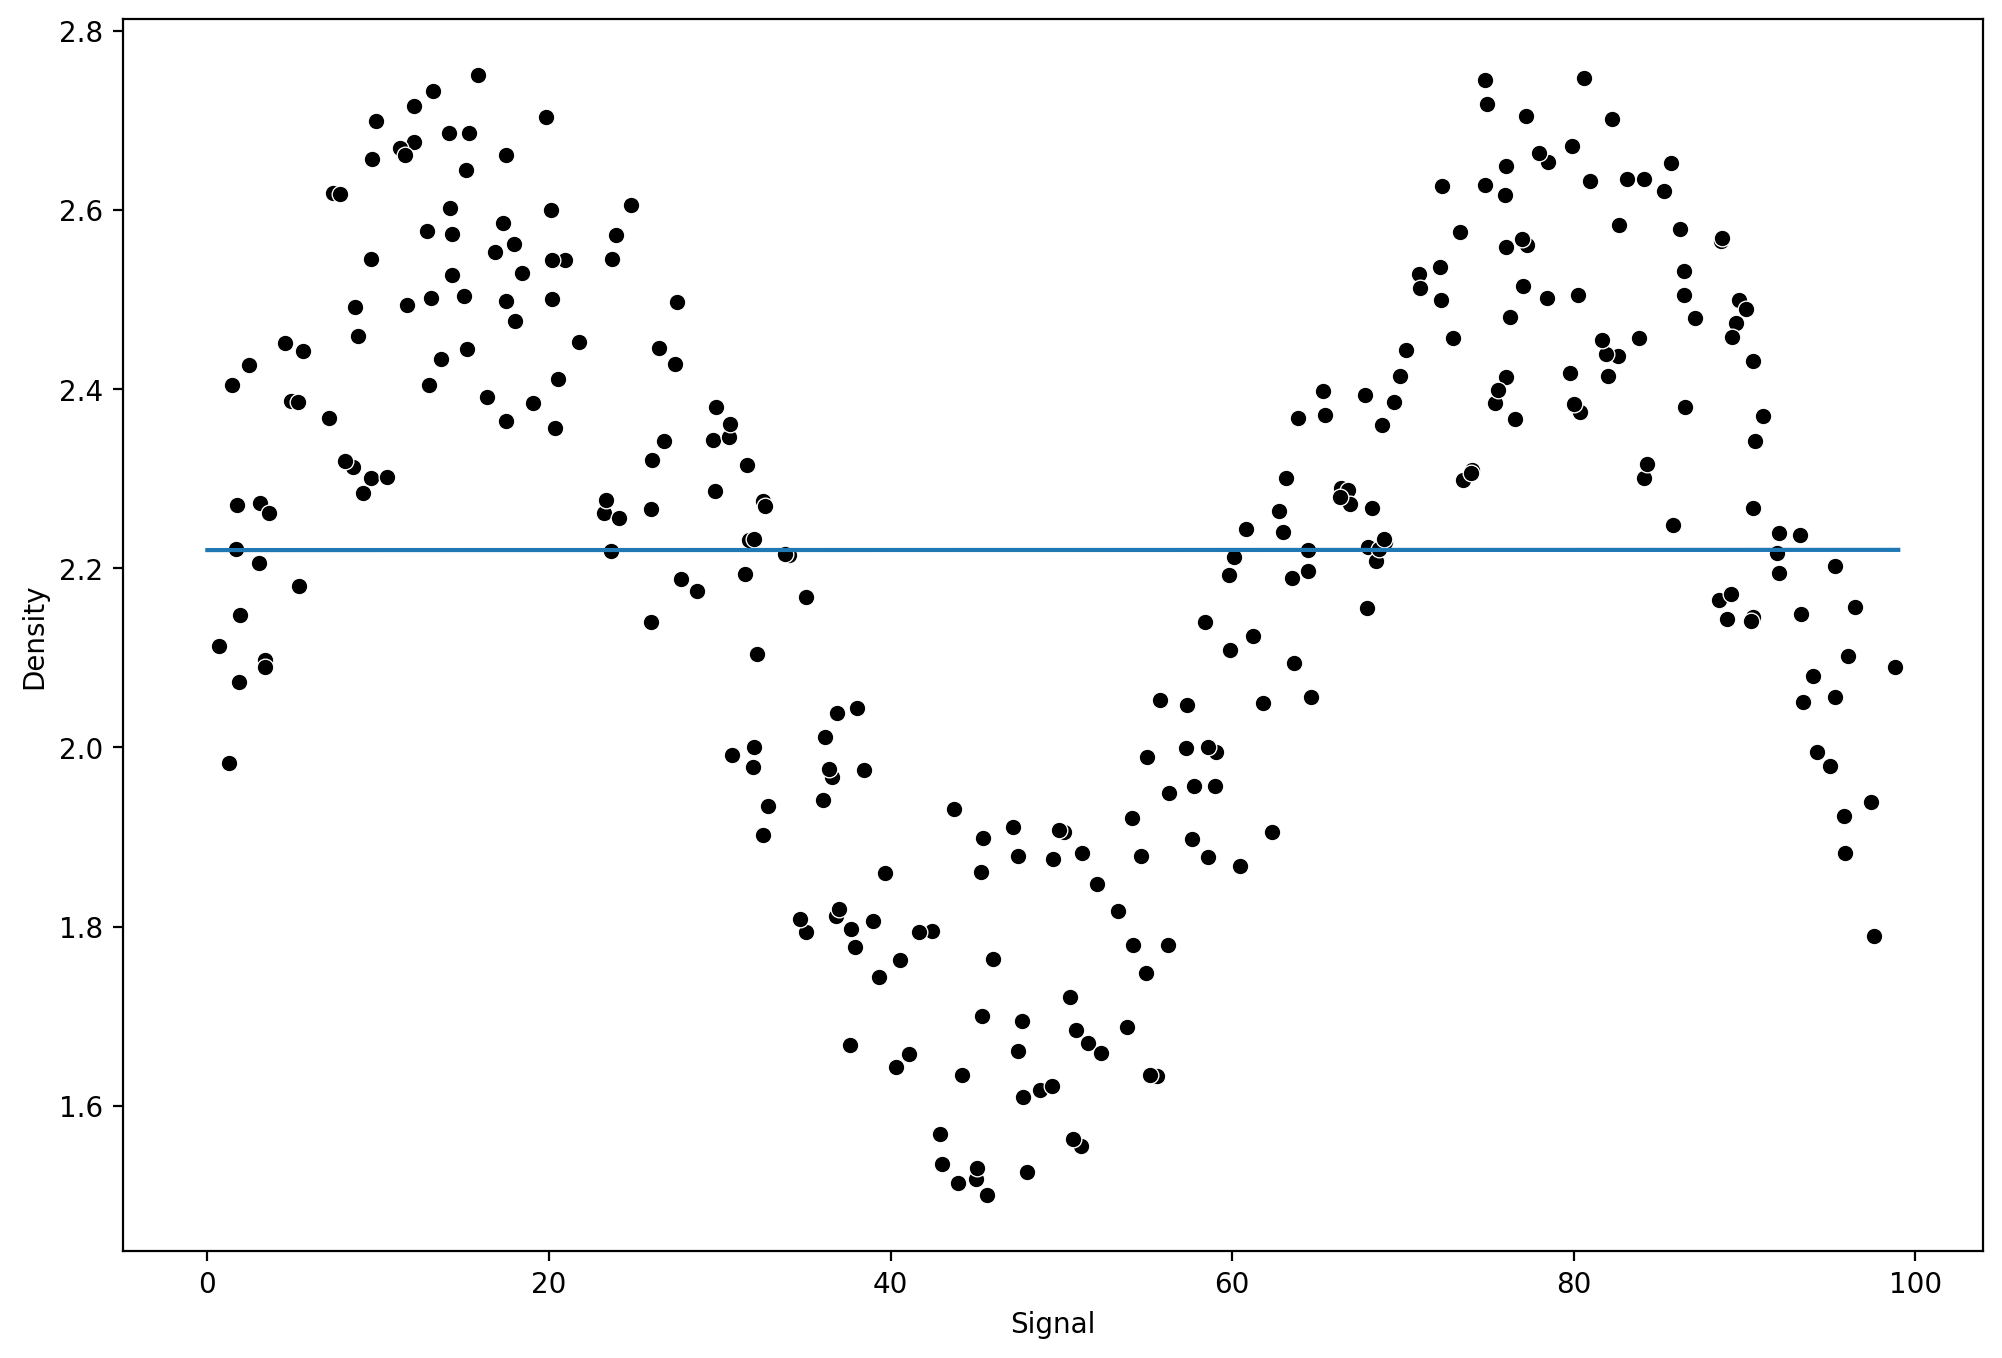

In [54]:
model=LinearRegression()
run_model(model,X_train,X_test,y_train,y_test)


In [55]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [59]:
pipe=make_pipeline(PolynomialFeatures(degree=10),LinearRegression())

RMSE:0.16269005292854596
MAE:0.1433857719391462


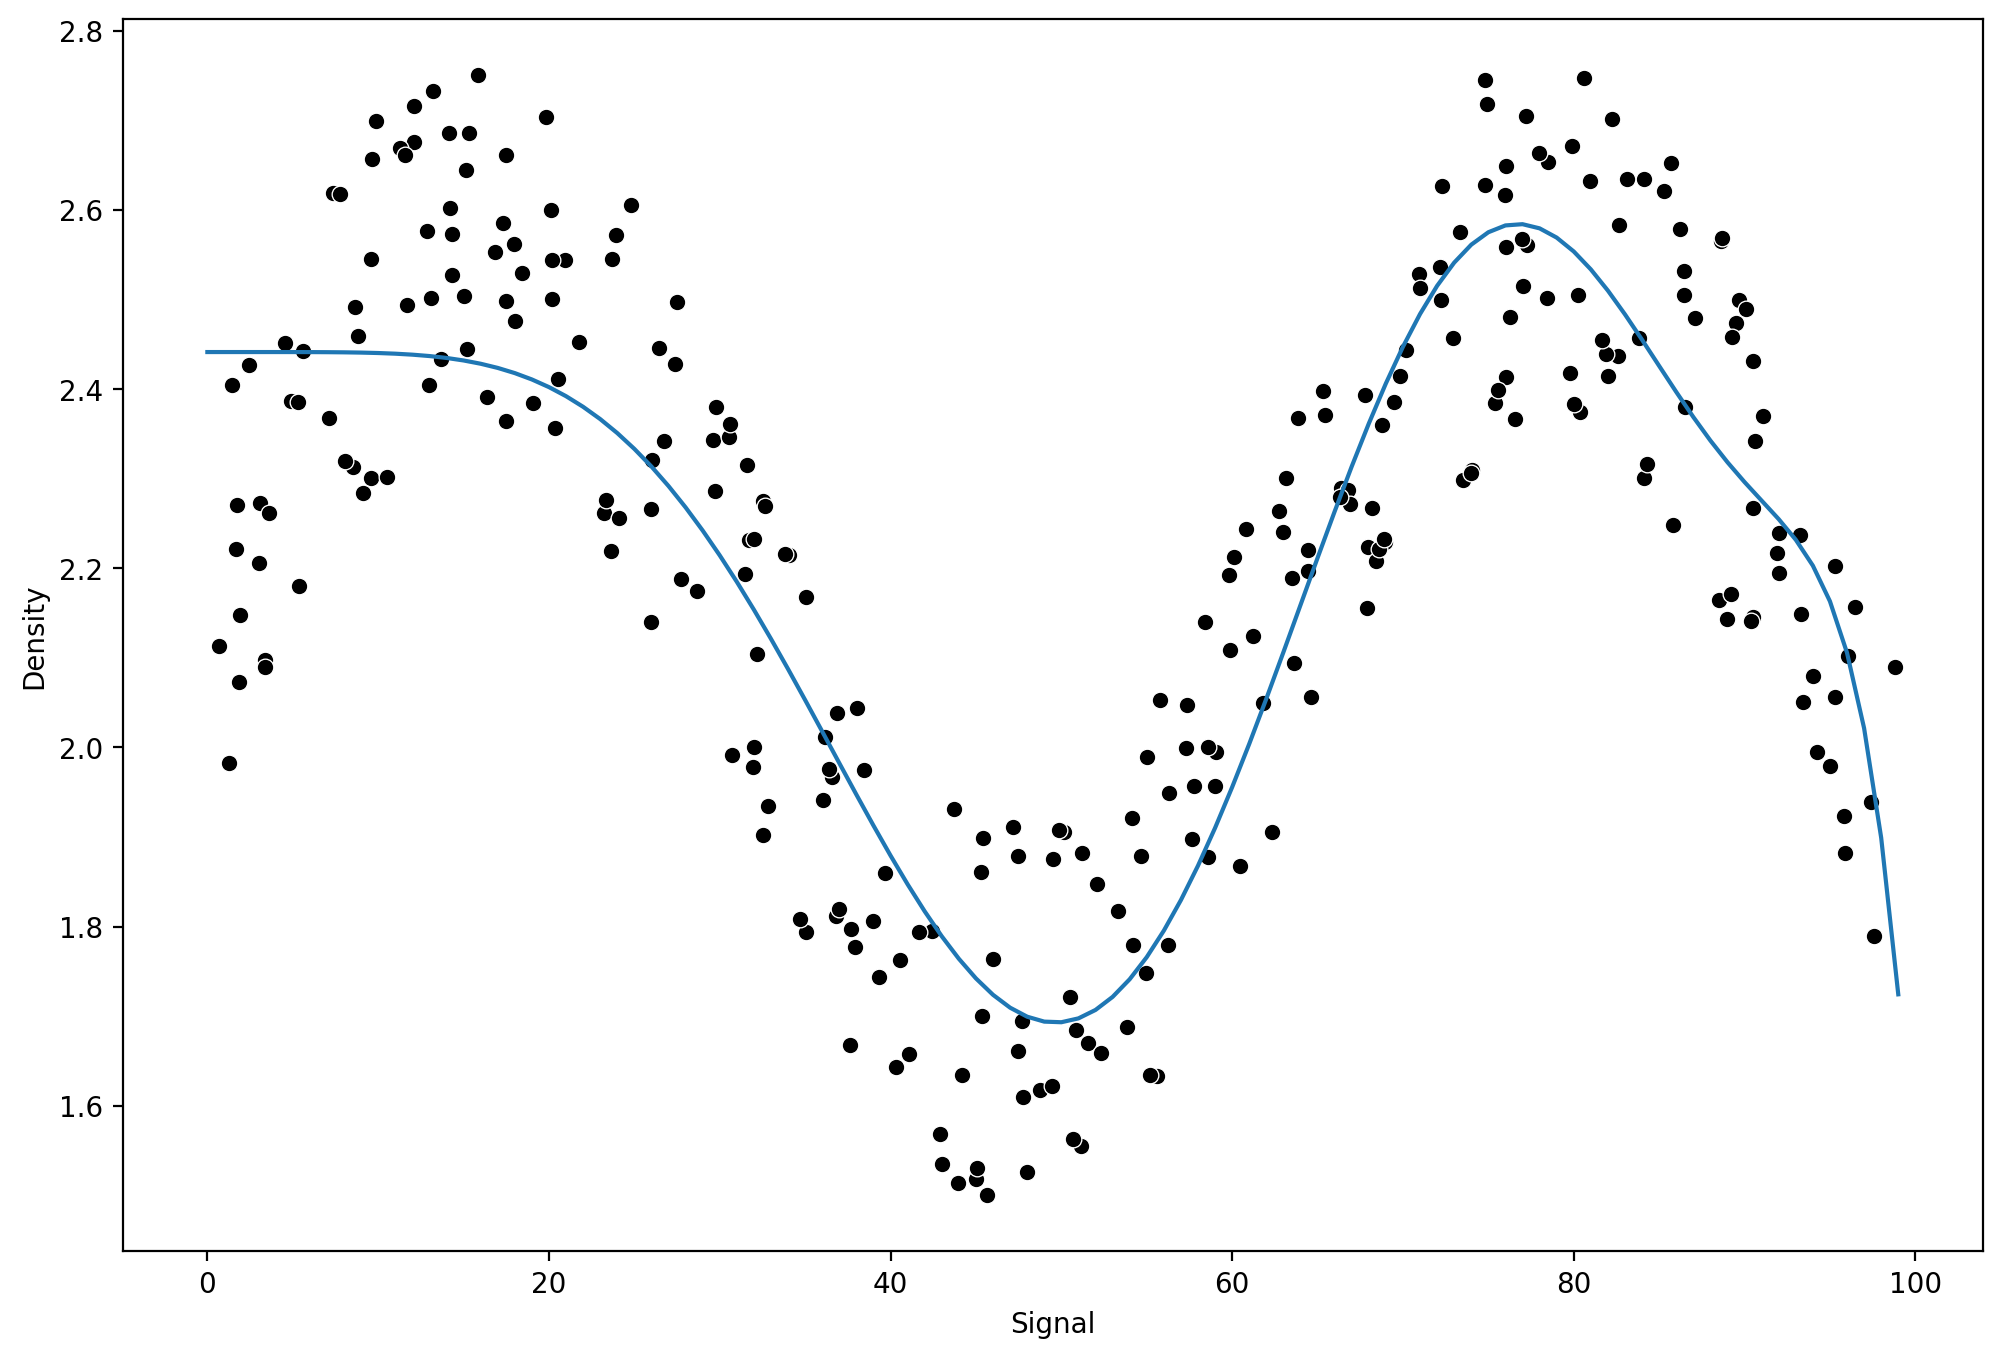

In [60]:
run_model(pipe,X_train,X_test,y_train,y_test)

In [61]:
from sklearn.neighbors import KNeighborsRegressor

RMSE:0.1523487028635337
MAE:0.11877297474442378
RMSE:0.13730685016923647
MAE:0.12198383614100558
RMSE:0.13277855732740926
MAE:0.11635971693292672


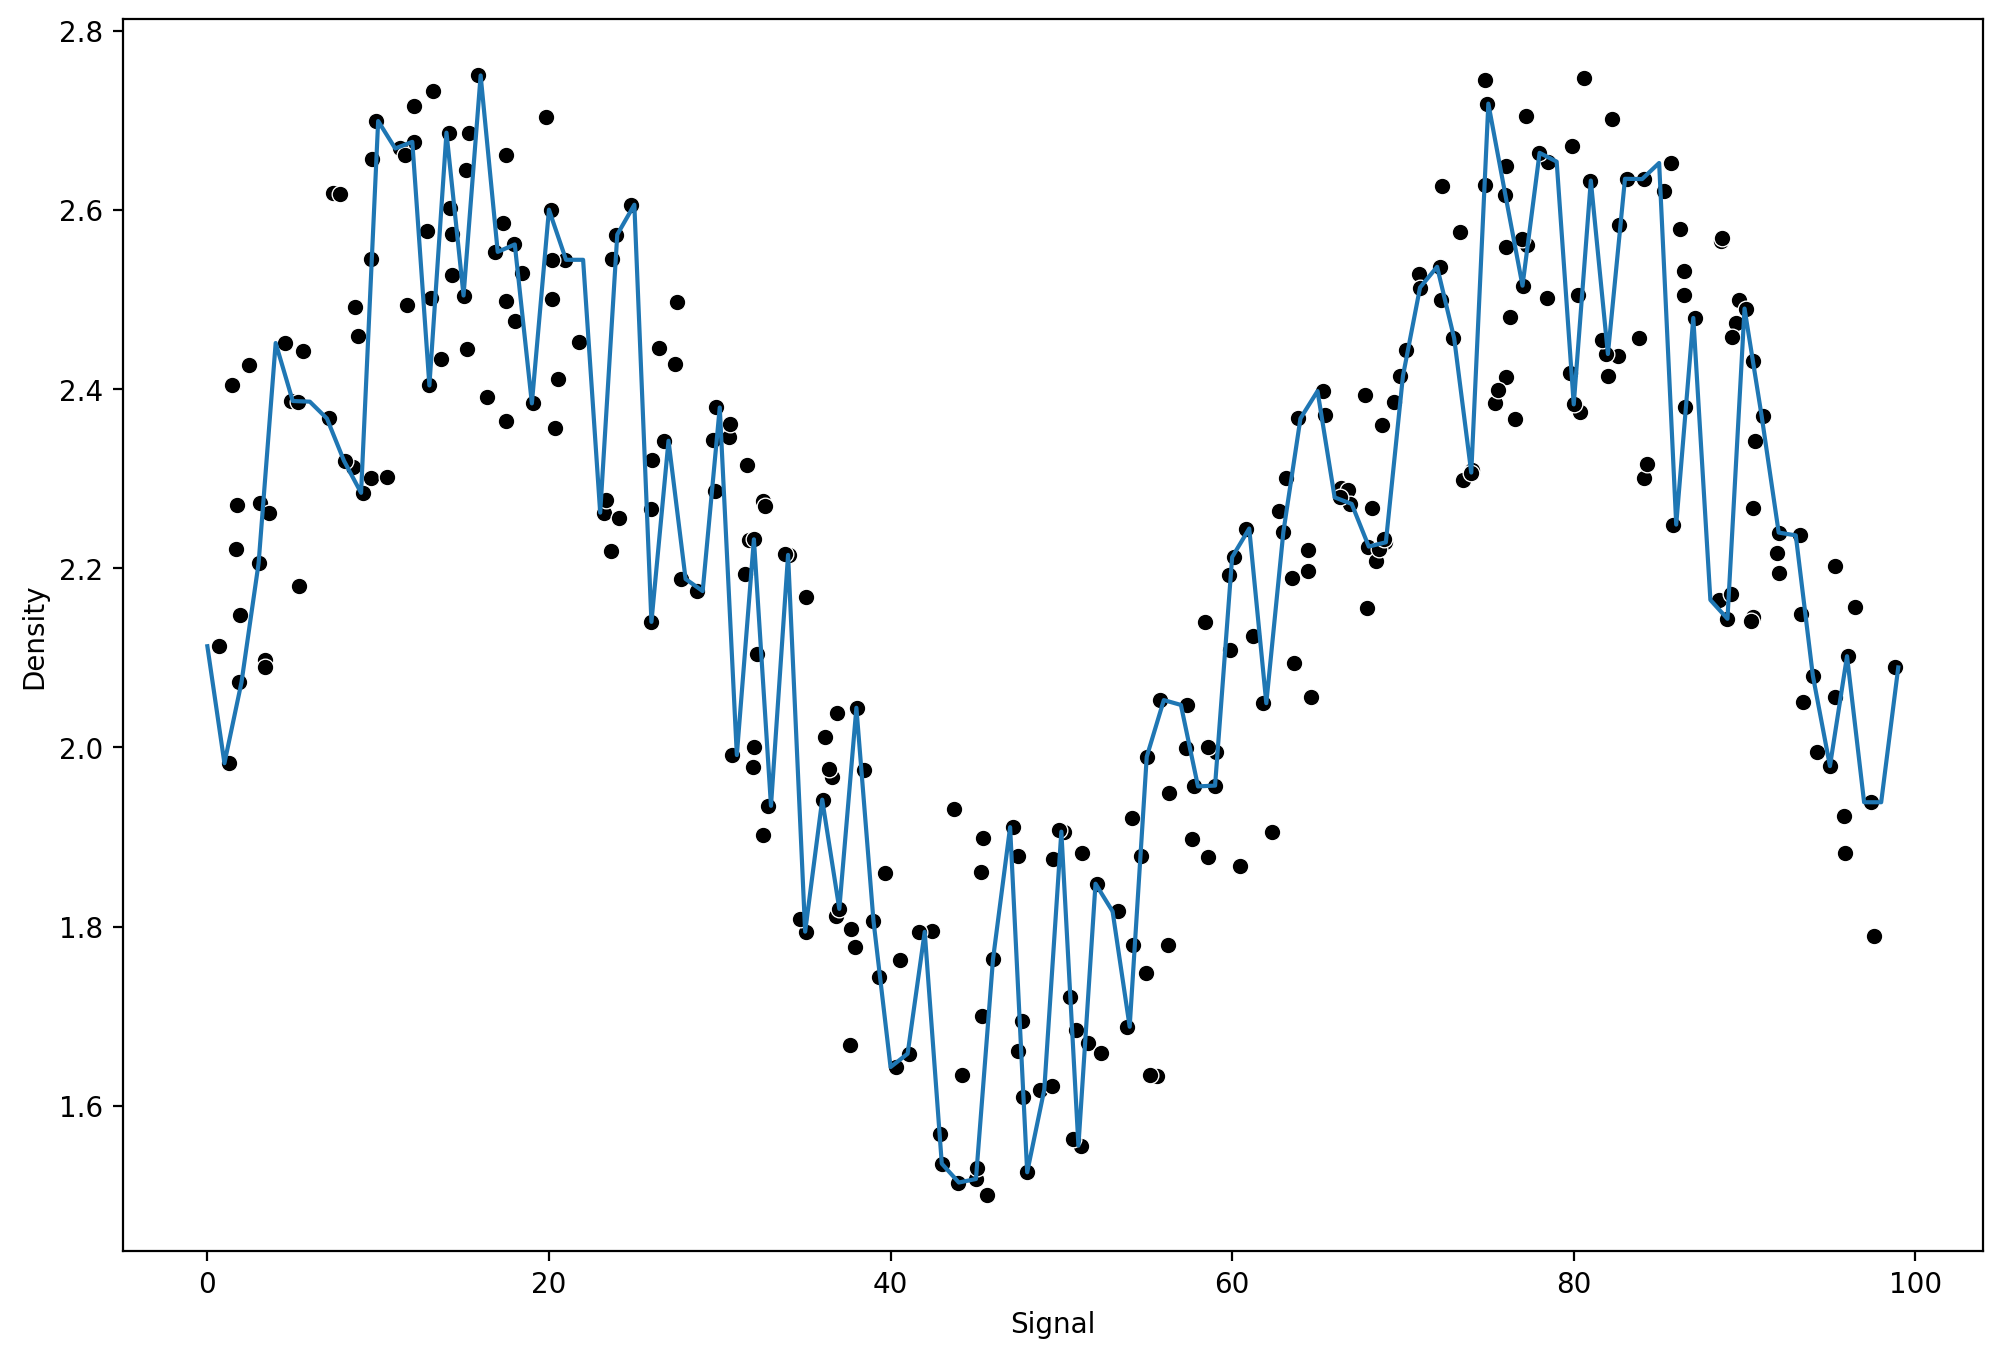

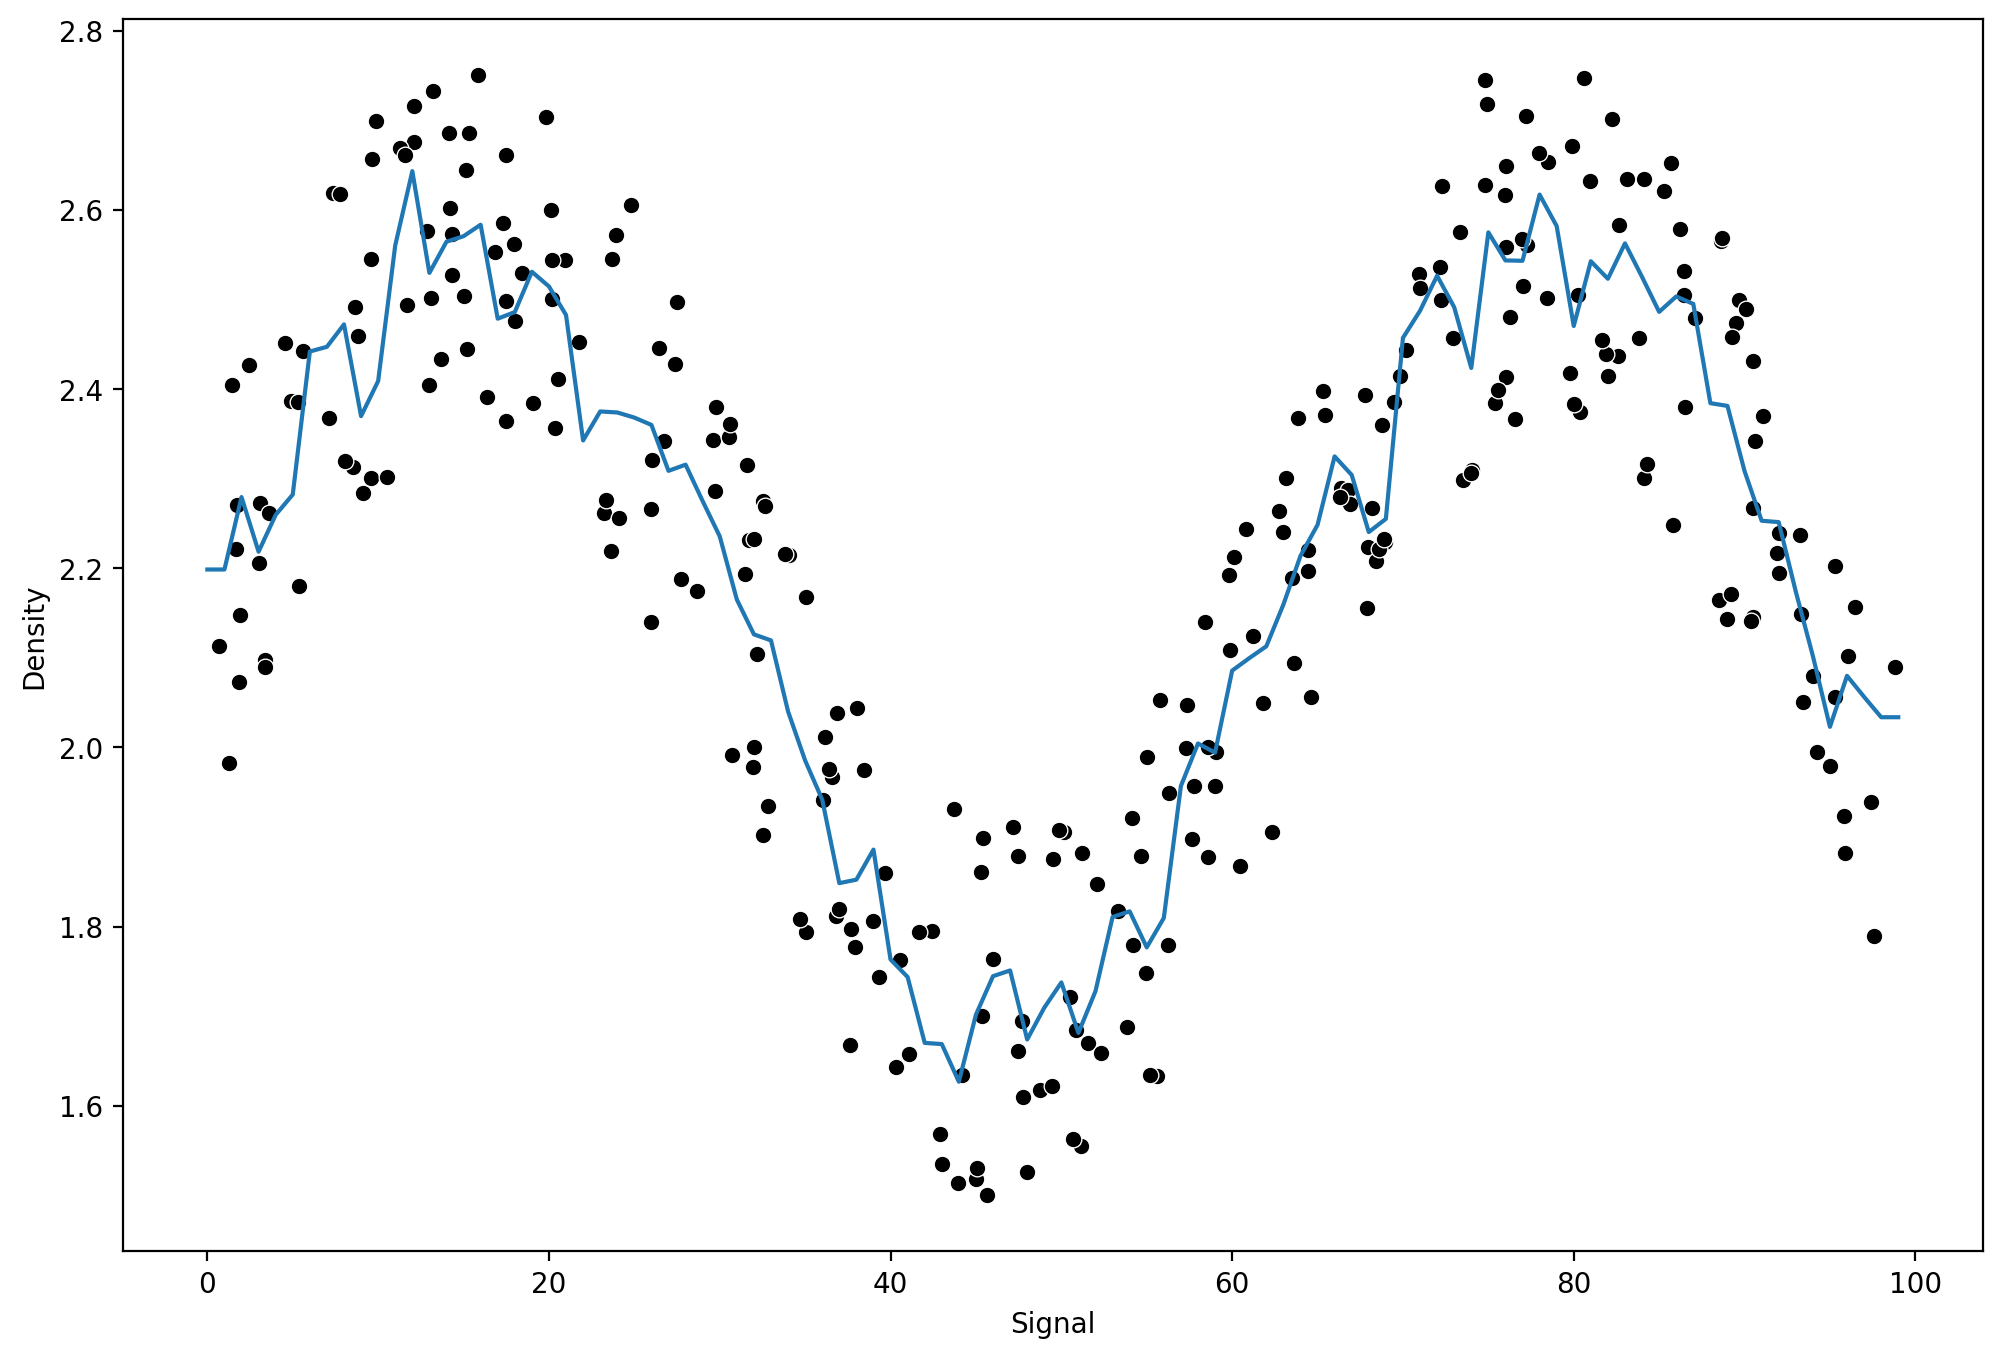

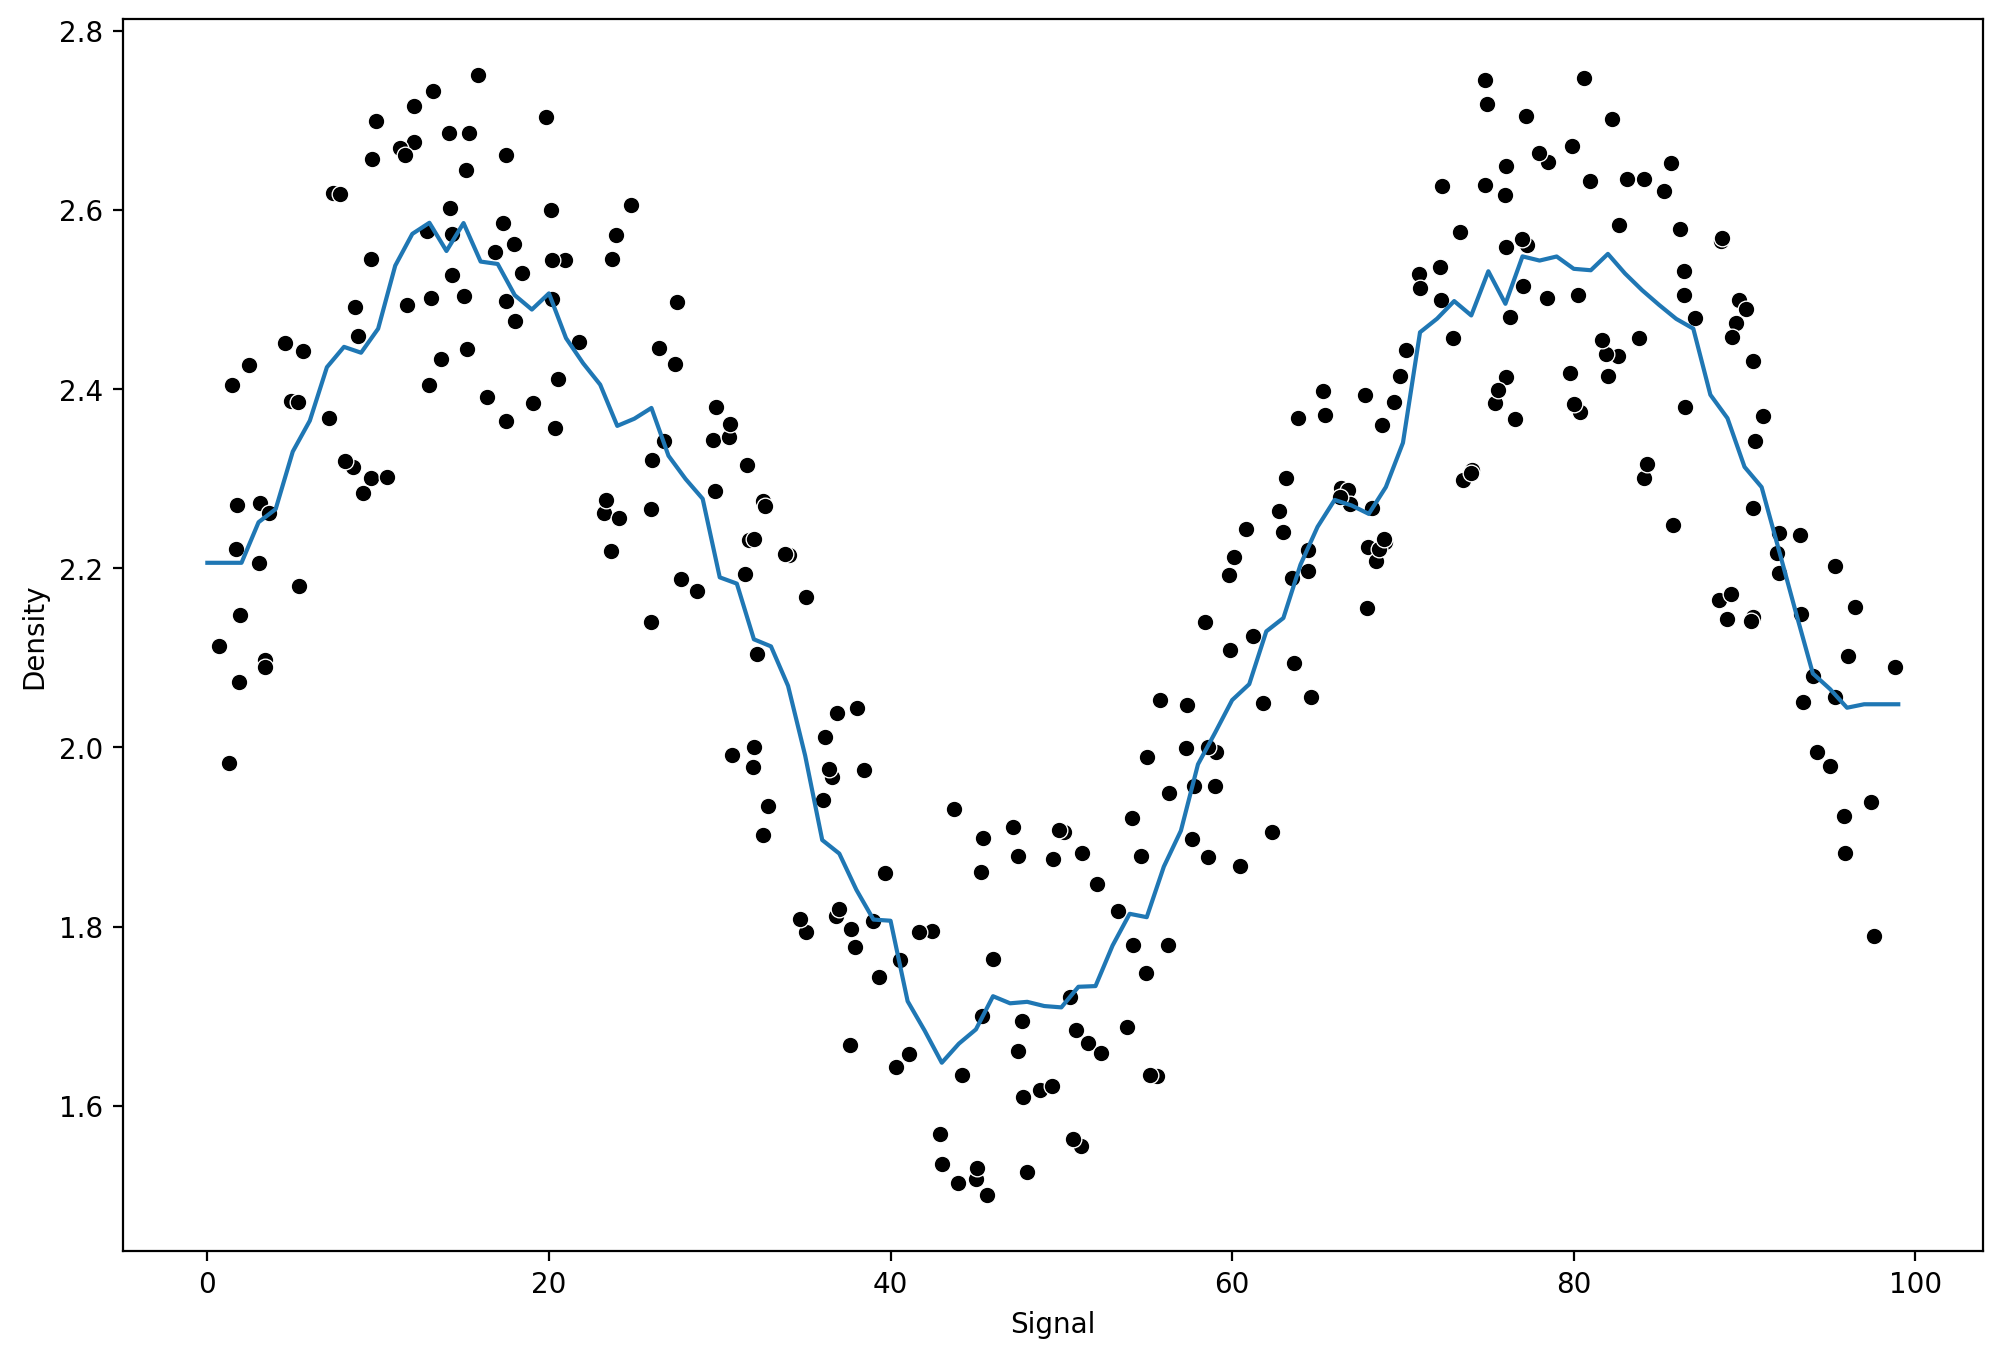

In [65]:
k_values=[1,5,10]

for n in k_values:
    model=KNeighborsRegressor(n_neighbors=n)
    run_model(model,X_train,X_test,y_train,y_test)

In [73]:
from sklearn.tree import DecisionTreeRegressor

RMSE:0.1523487028635337
MAE:0.11877297474442378


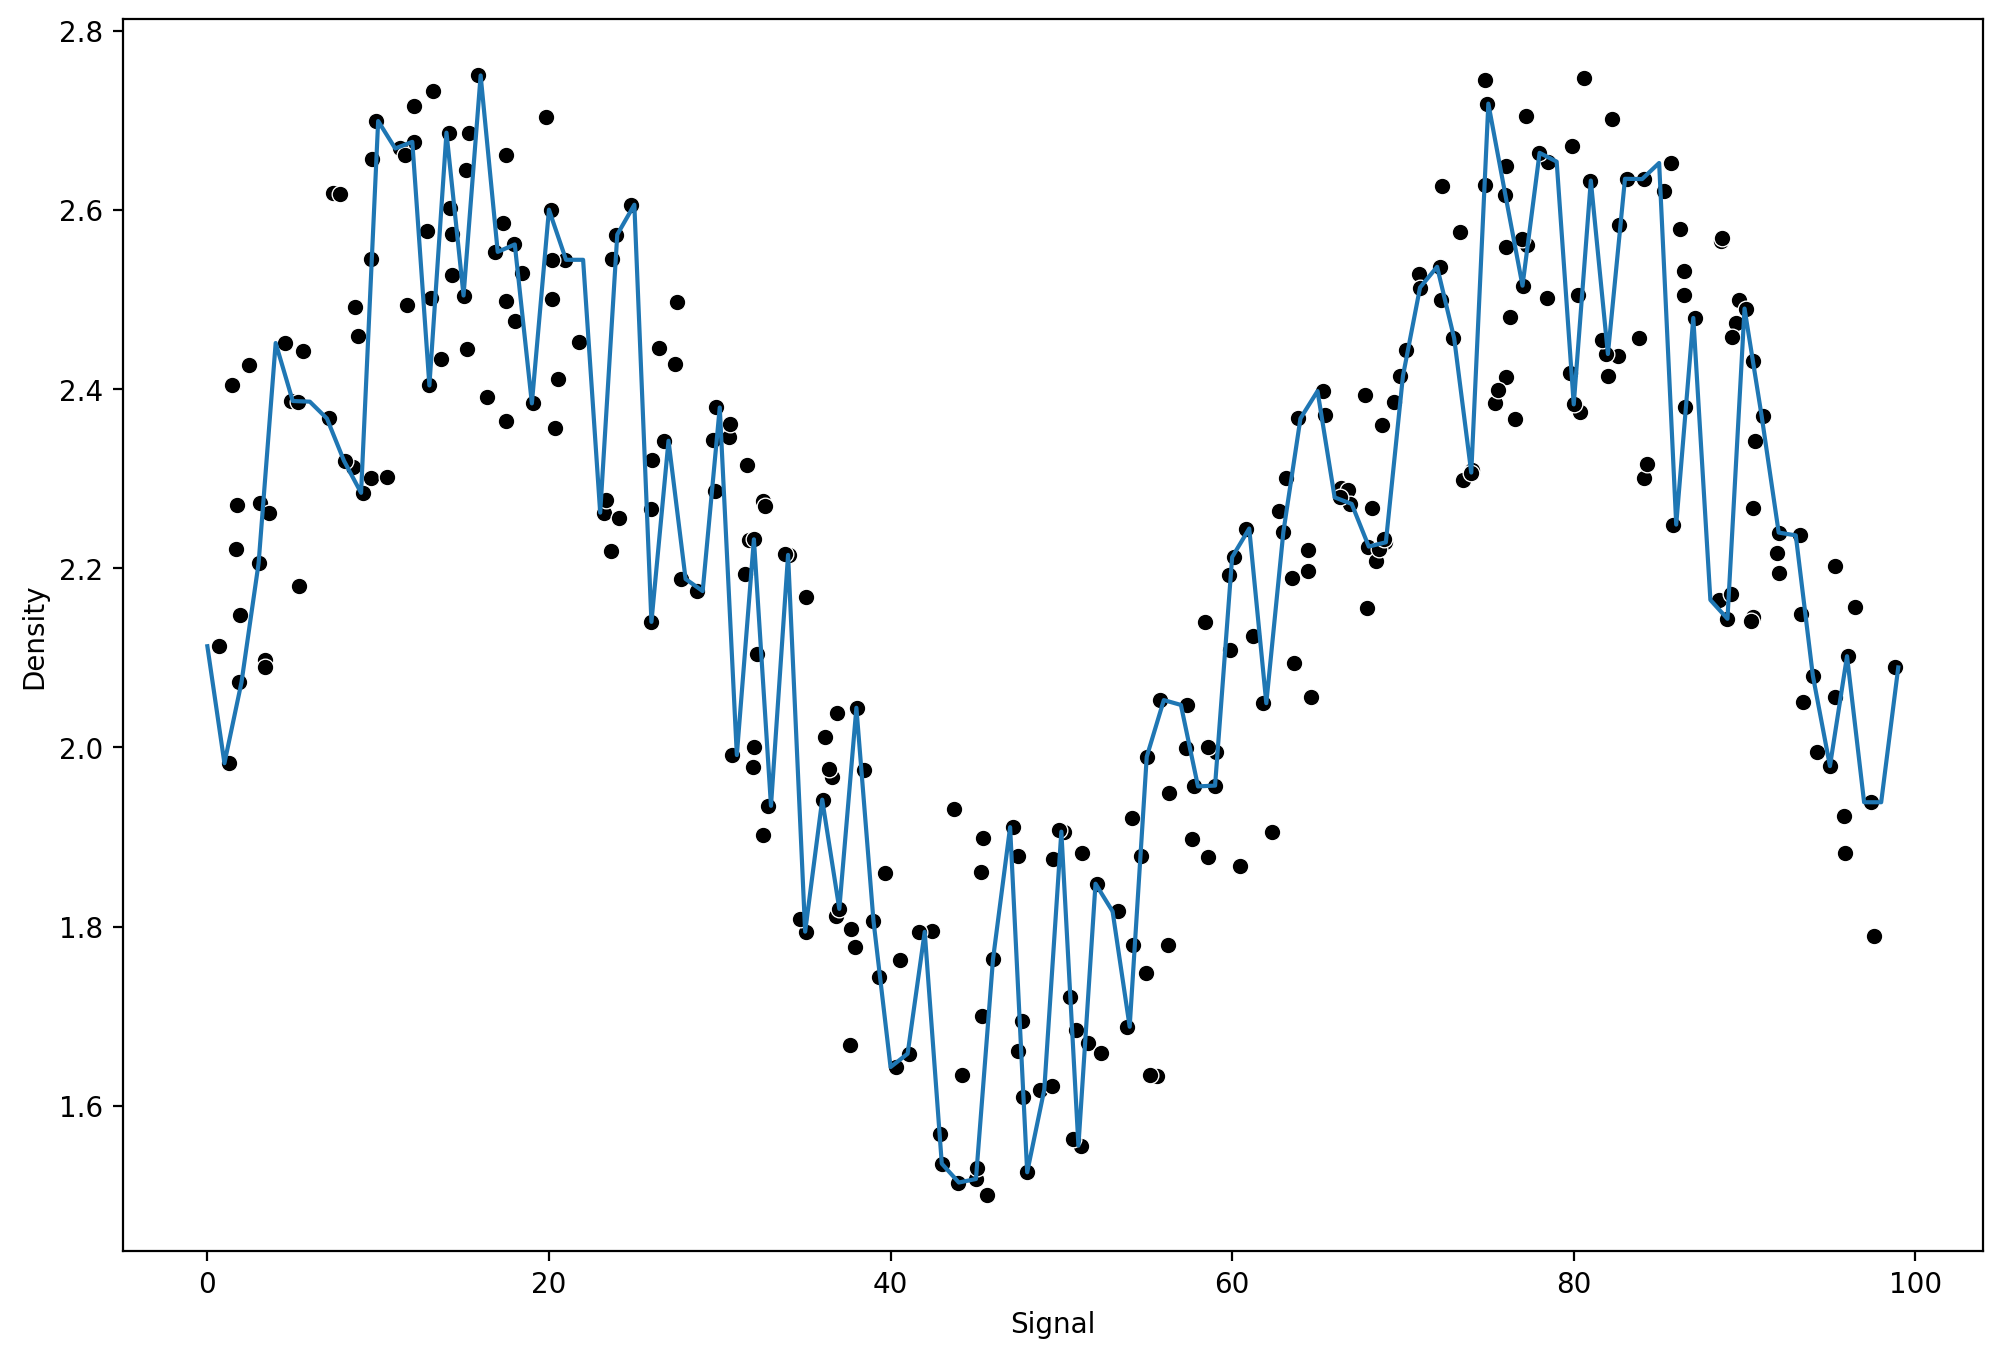

In [74]:
model=DecisionTreeRegressor()
run_model(model,X_train,X_test,y_train,y_test)

In [76]:
from sklearn.svm import SVR

In [75]:
from sklearn.model_selection import GridSearchCV

In [78]:
svr=SVR()
param_grid={'C':[0.01,0.1,1,5,10,100,1000],
'gamma':['auto','scale']}

grid=GridSearchCV(svr,param_grid)

RMSE:0.12646999302046696
MAE:0.10854210121348368


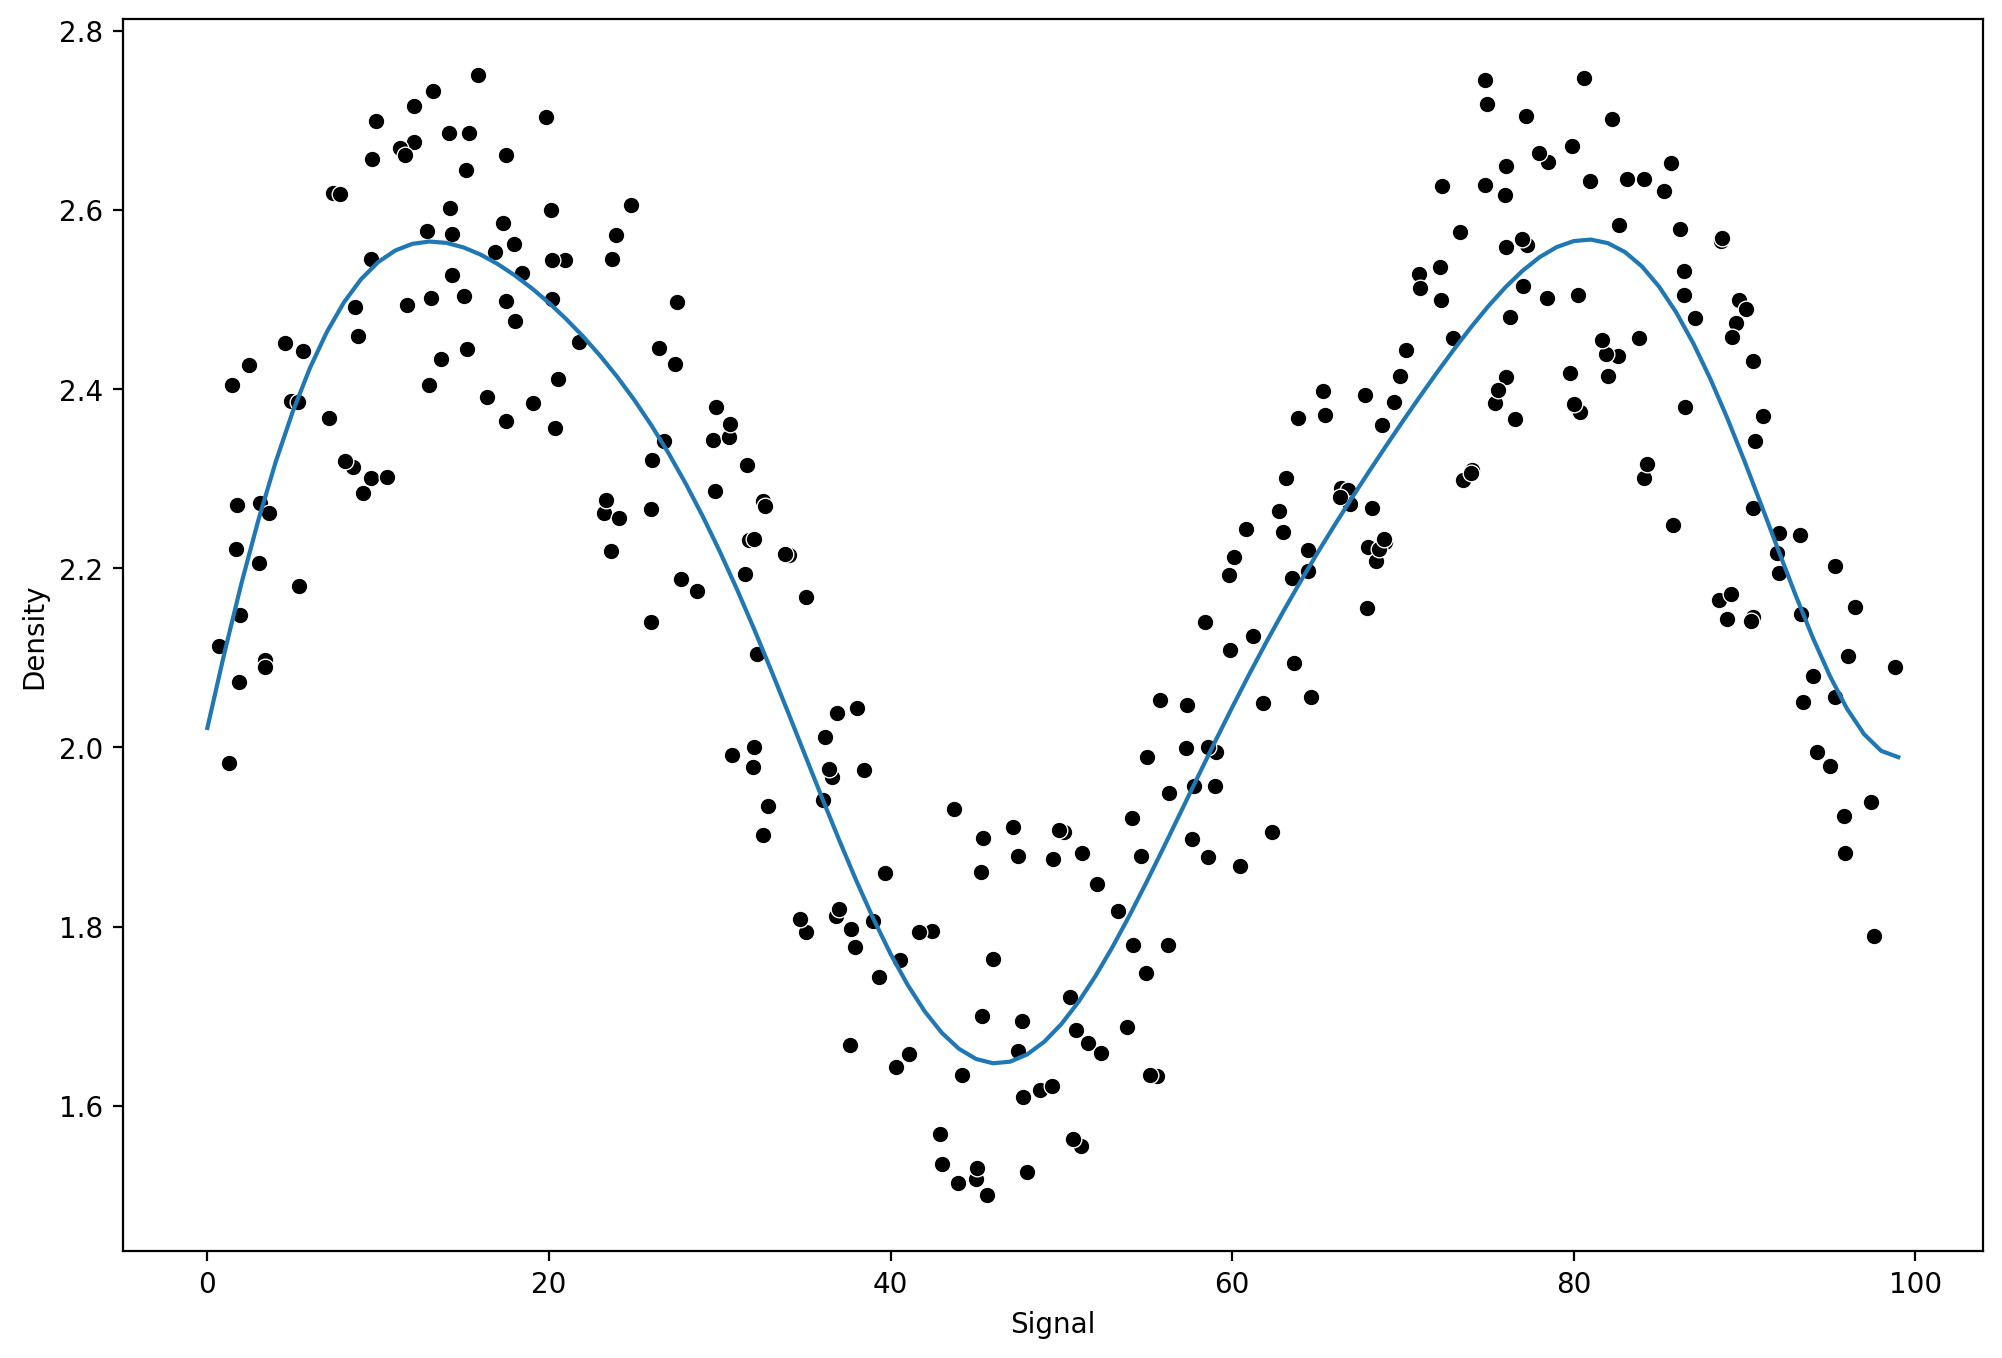

In [79]:
run_model(grid,X_train,X_test,y_train,y_test)

In [80]:
grid.best_params_

{'C': 1000, 'gamma': 'scale'}

In [81]:
from sklearn.ensemble import RandomForestRegressor

In [82]:
rf=RandomForestRegressor(n_estimators=10)

RMSE:0.1308017719764597
MAE:0.1056726478543366


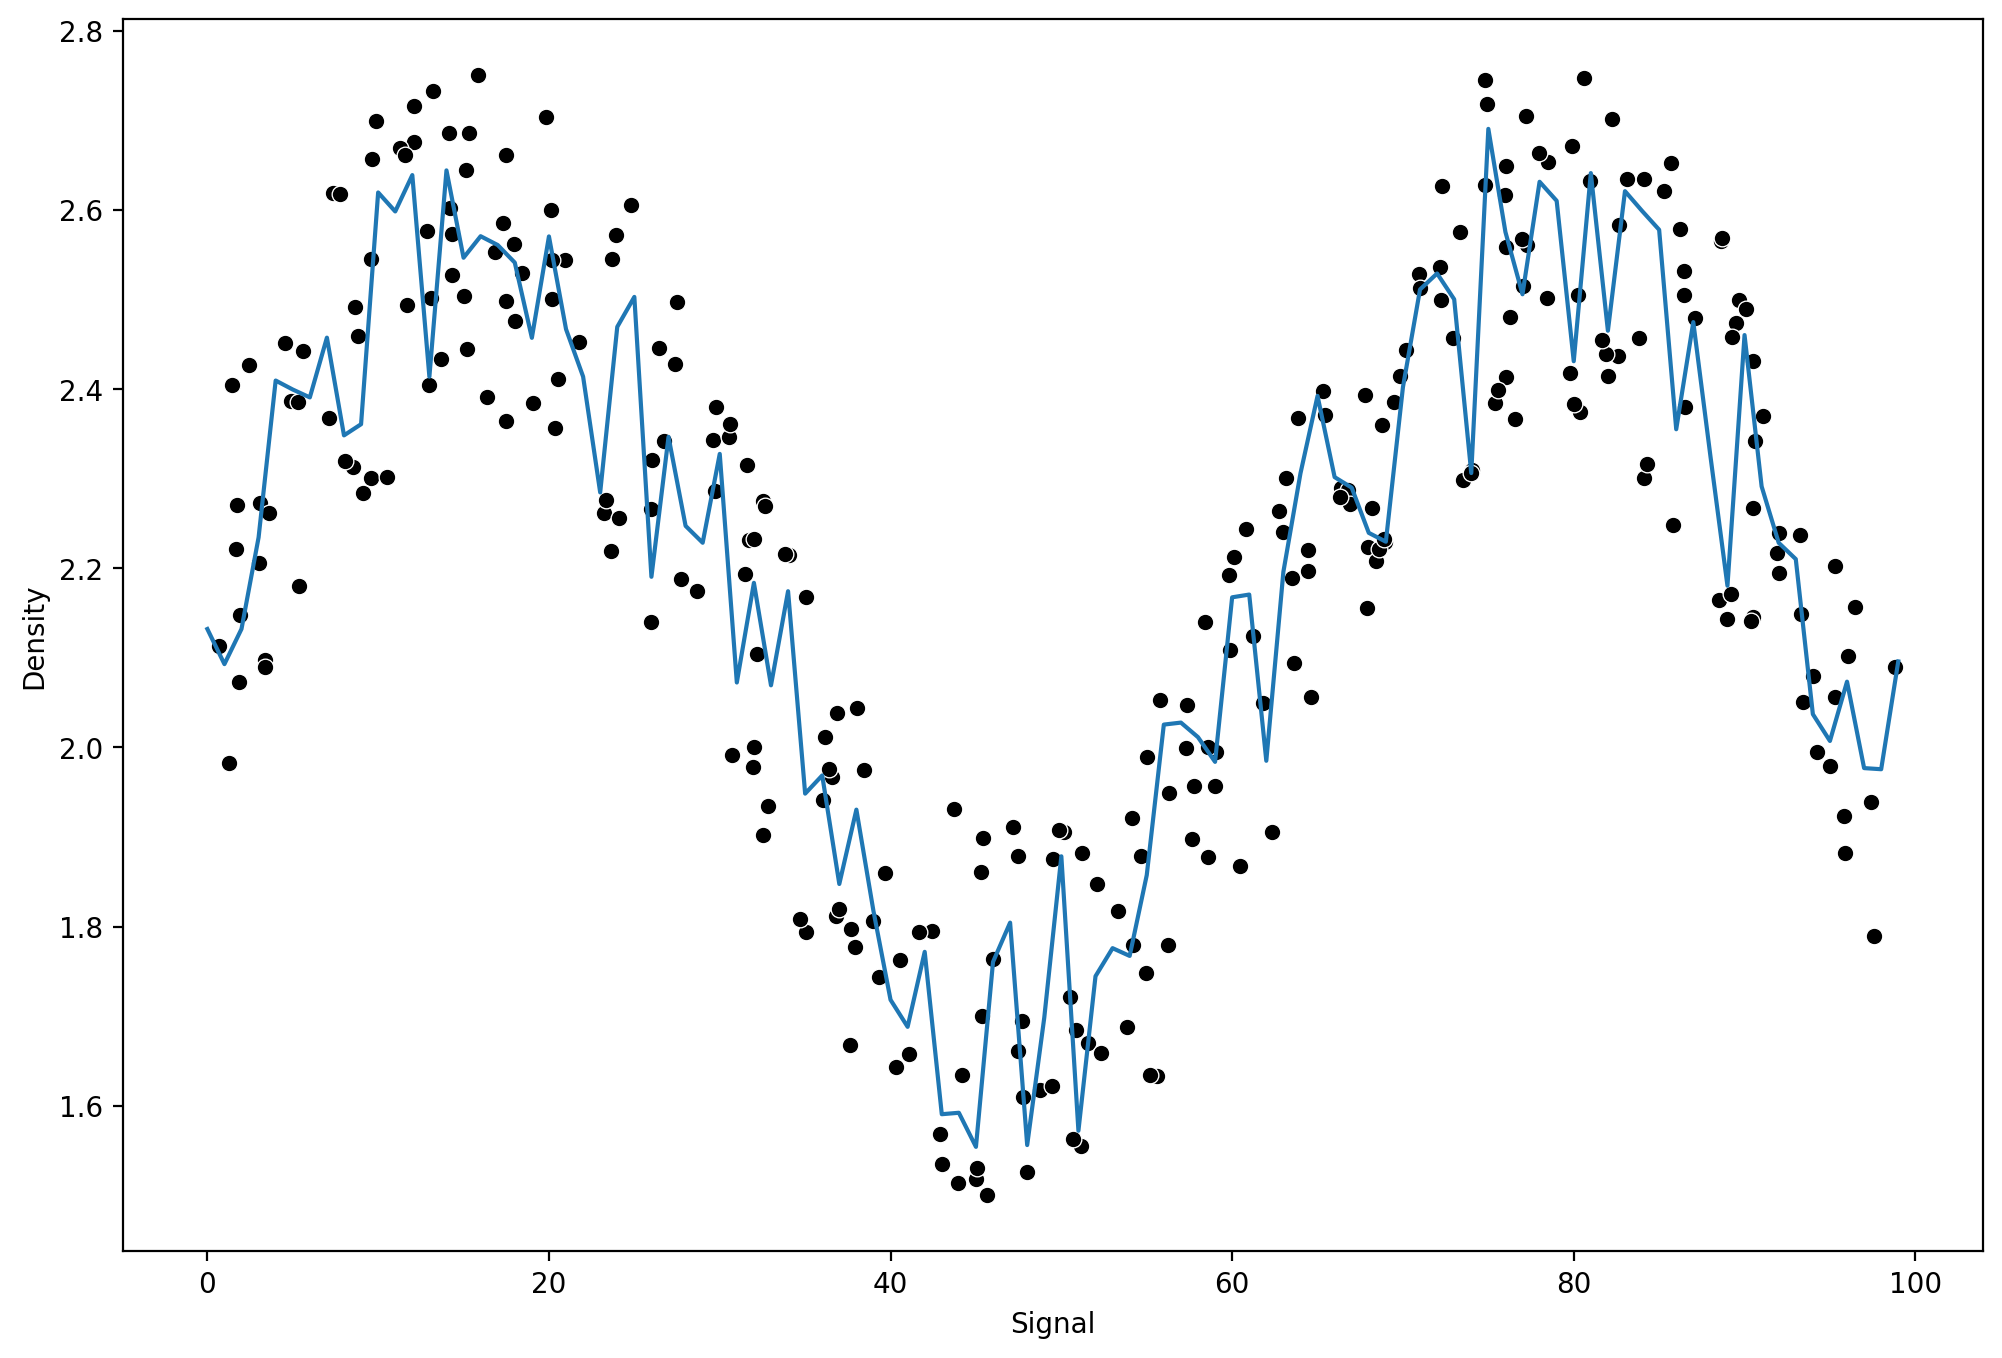

In [83]:
run_model(rf,X_train,X_test,y_train,y_test)

In [84]:
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor

In [85]:
model=GradientBoostingRegressor()

RMSE:0.13294148649584667
MAE:0.11318284854800689


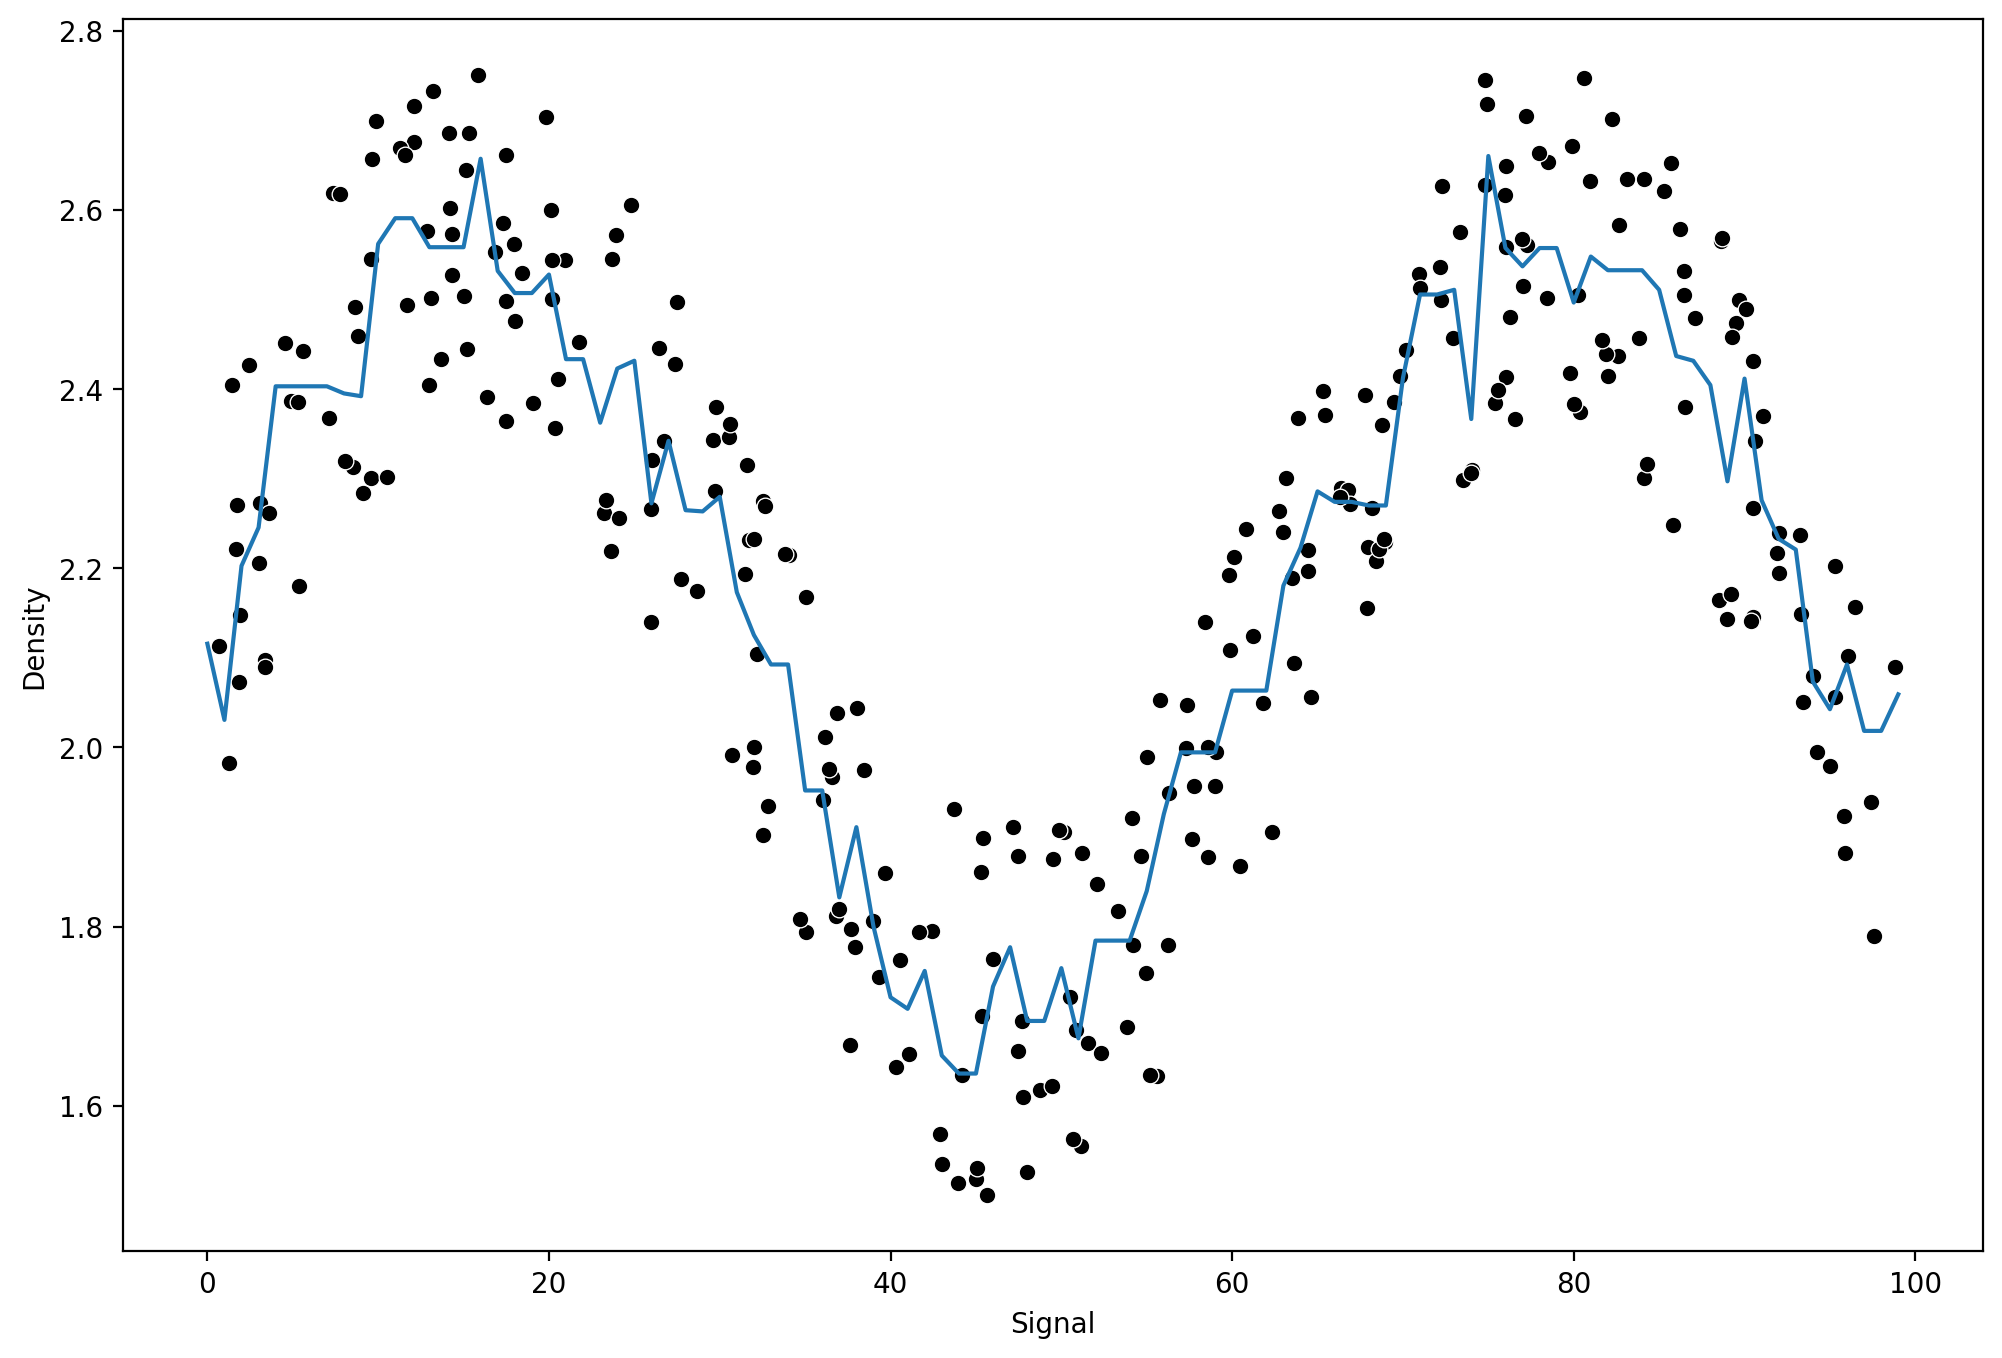

In [86]:
run_model(model,X_train,X_test,y_train,y_test)

RMSE:0.13782536363093198
MAE:0.11821545014115313


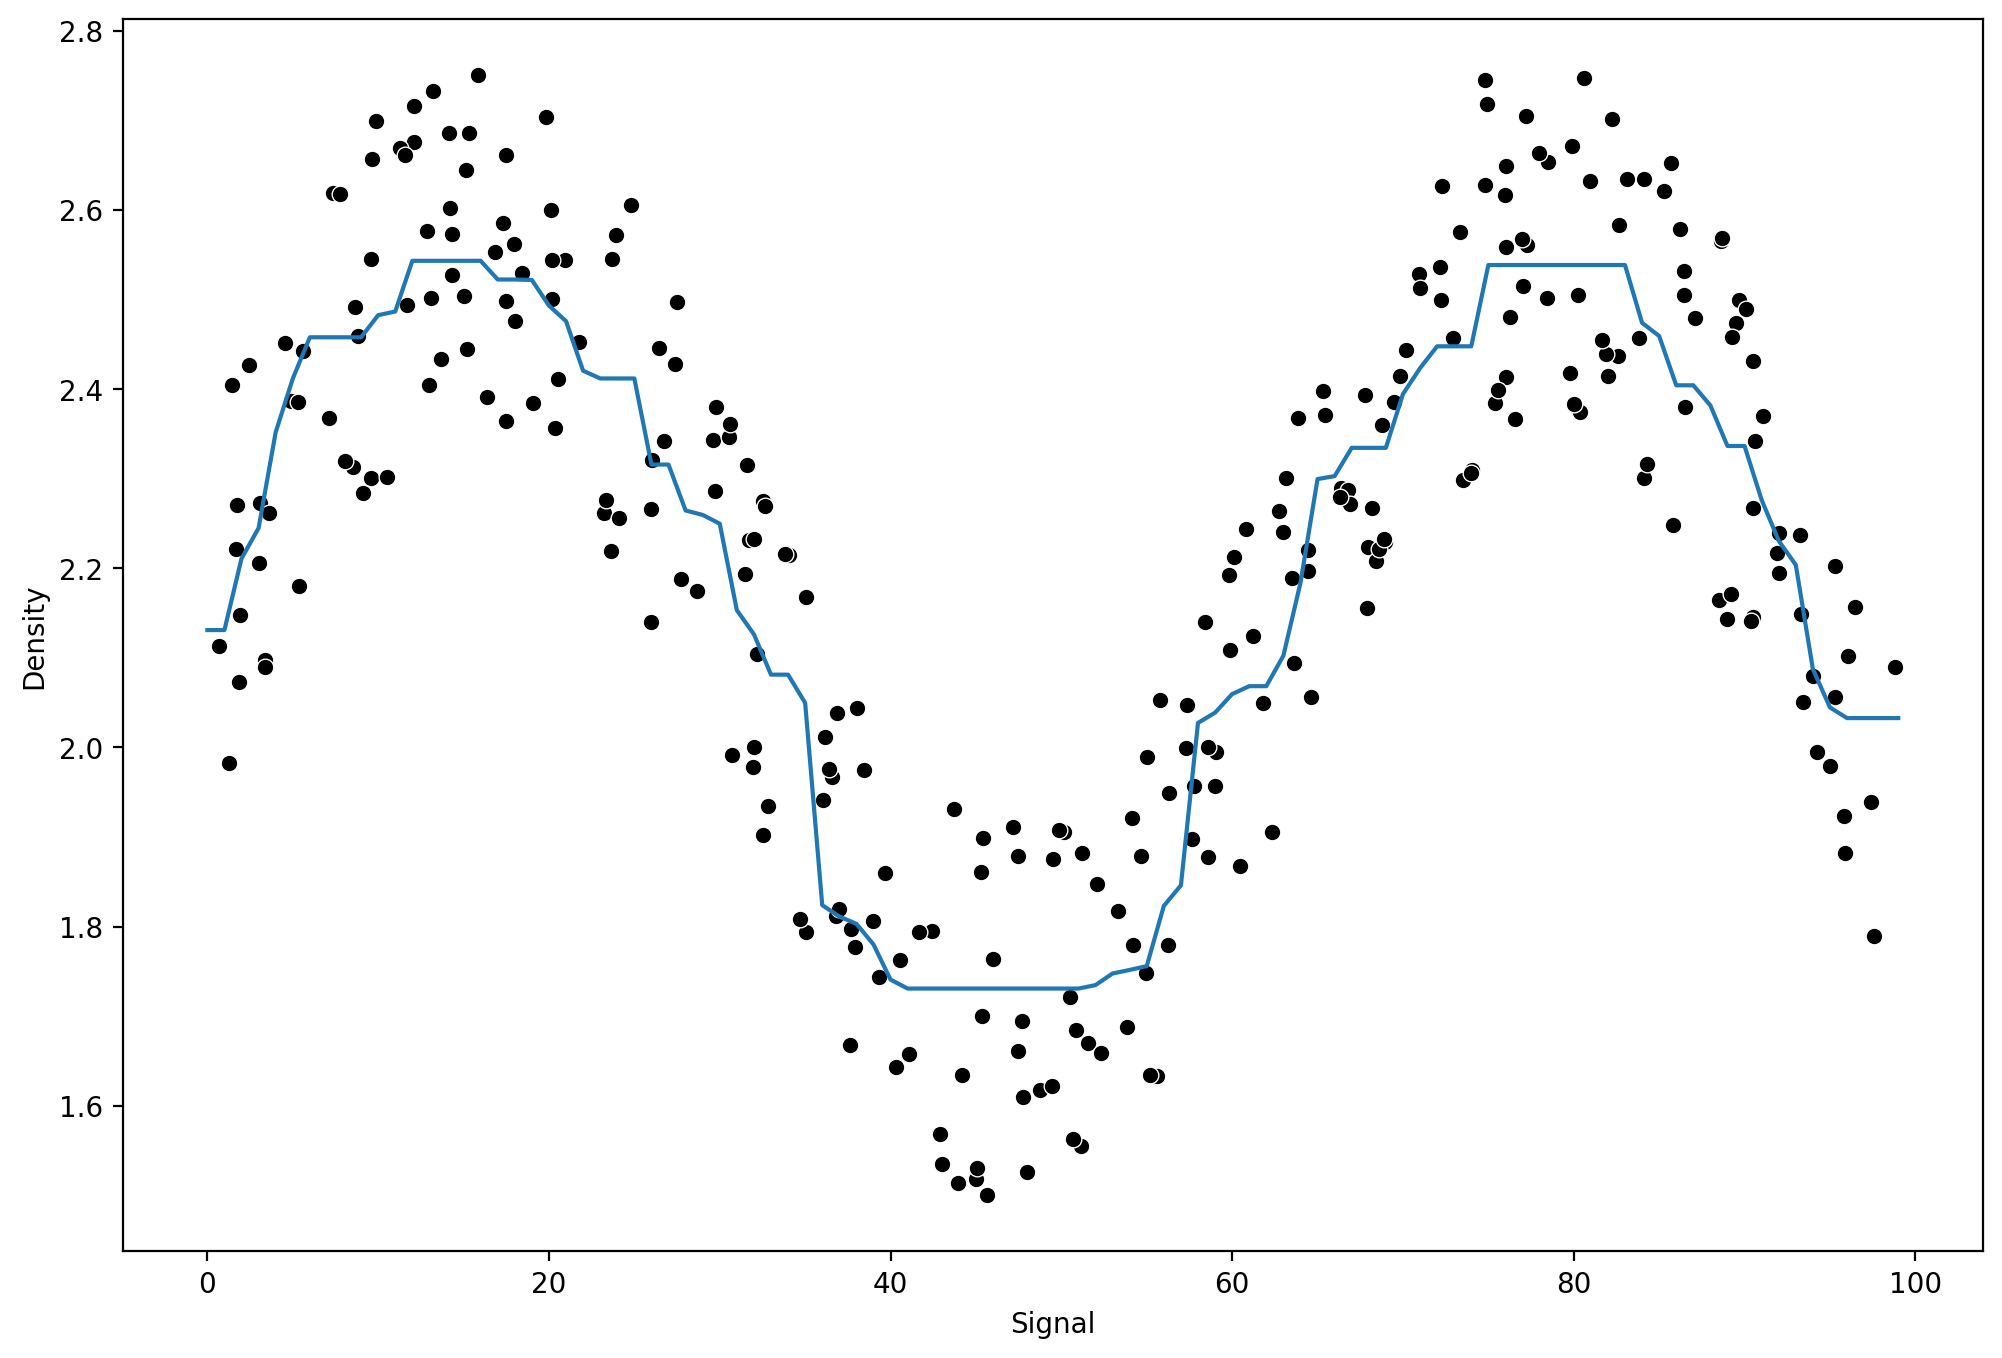

In [87]:
model=AdaBoostRegressor()
run_model(model,X_train,X_test,y_train,y_test)